In [15]:
import sys

from pathlib import Path

ROOT_DIR = Path().resolve().parents[0]
sys.path.insert(0, str(ROOT_DIR))

from bout_dump import BOUTHESELInfo
from bout_phys import BOUTHESELPhys

root = ROOT_DIR / r"sim_data/Alexander__grid_c_0"
info = BOUTHESELInfo(root)
phys = BOUTHESELPhys(info)

In [16]:
# for (section, name), value in info.settings.items():
#     print(f'{section},{name} = {value}')

# for field, value in info.data.__dict__.items():
#     print(f'{field} = {value.shape}')

# for field, value in info.parameters.__dict__.items():
#     print(f'{field} = {value}')

# for name, foo in info.functions.__dict__.items():
#     print(f'{name} = {foo}')

3D fields: ['lnn', 'lnpe', 'lnpi', 'phi', 'vort']
2D fields: ['init_n', 'init_pe', 'init_pi', 'sigma_open', 'sigma_closed', 'sigma_force']
Skipped scalar fields: ['dz', 'Bt', 'q', 'Te0', 'Ti0', 'n0', 'Rmajor', 'Rminor', 'A', 'Z', 'Mach', 'x_lcfs', 'x_wall', 'force_time', 'floor_time', 'floor_n', 'floor_pe', 'floor_pi', 'B0', 'oci', 'rhoe', 'rhos', 'nuei', 'nuii', 'nuee', 'neoclass_correction_factor', 'lblob']


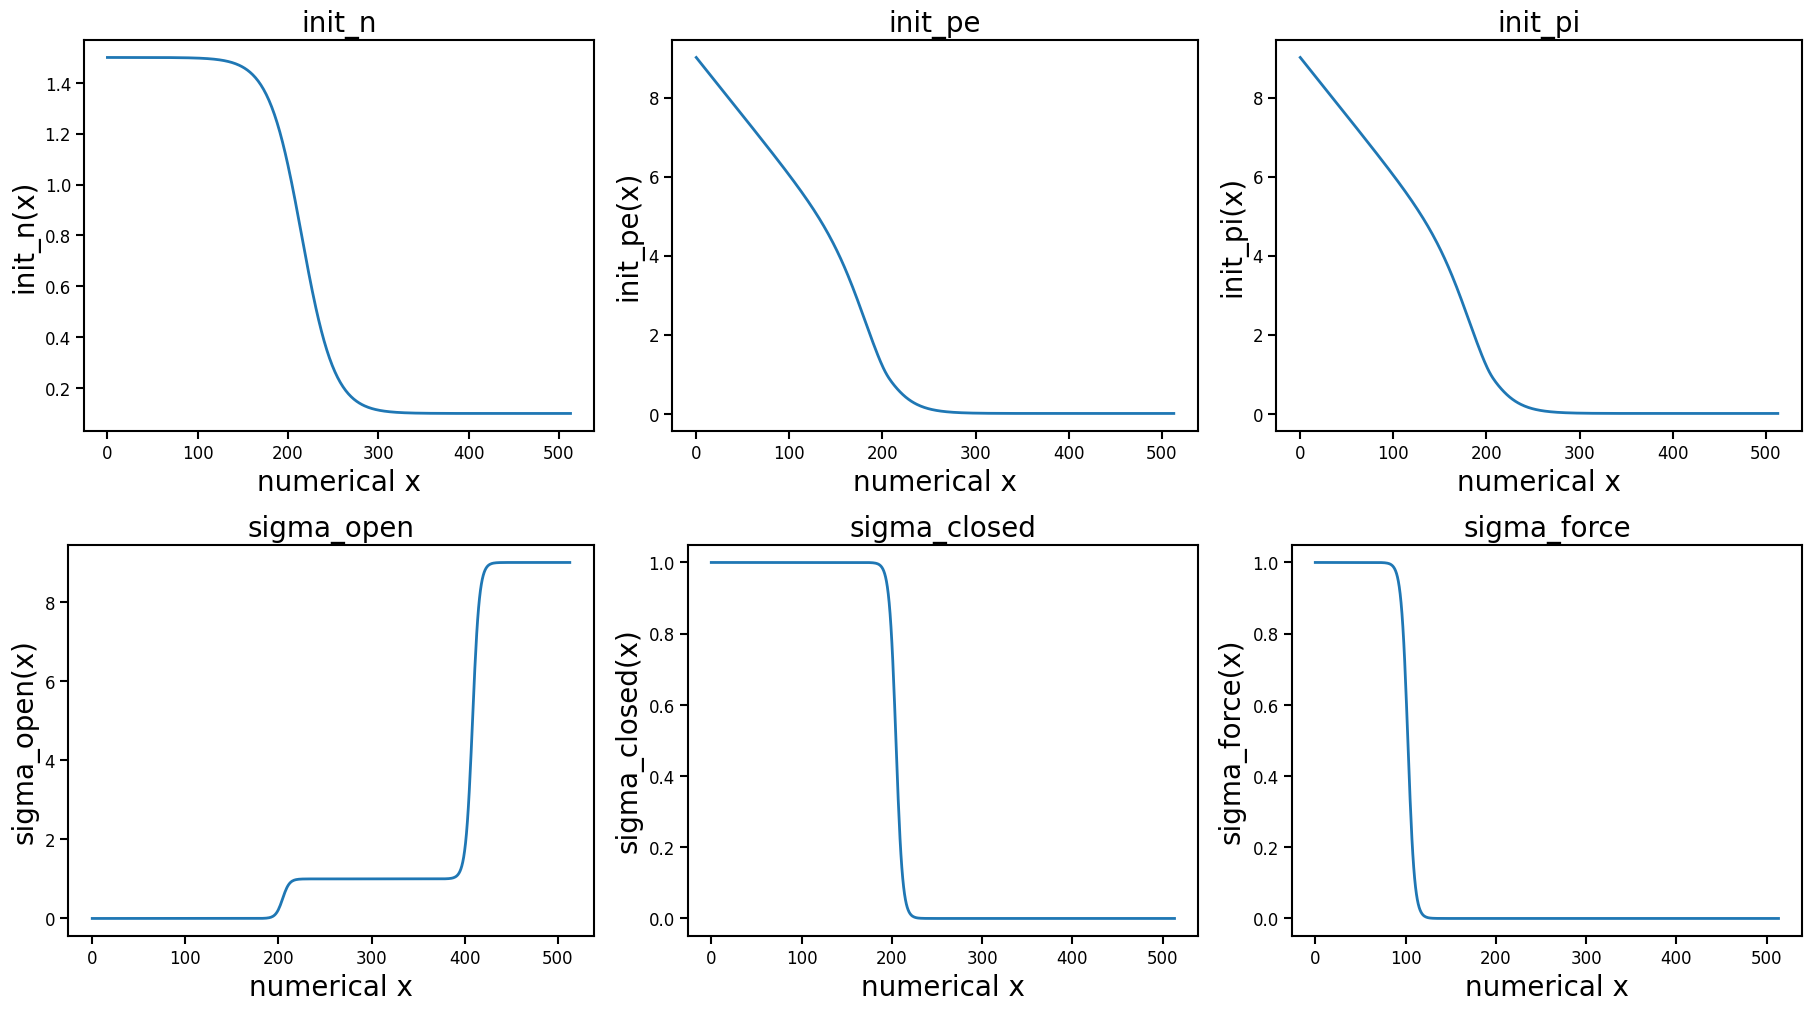

In [17]:

import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt

from math import ceil
from IPython.display import display


three_d_fields = []
two_d_fields = []
scalar_fields = []
time_array = info.data.t_array.detach().cpu().numpy()
for name, arr in info.data.__dict__.items():
    if arr is None or name == 't_array' or name == 'dx' or name == 'B' or name == 'lconn':
        continue
    if arr.ndim == 3:
        three_d_fields.append((name, arr))
    elif arr.ndim == 1:
        two_d_fields.append((name, arr))
    elif arr.ndim == 0:
        scalar_fields.append(name)

print('3D fields:', [name for name, _ in three_d_fields])
print('2D fields:', [name for name, _ in two_d_fields])
print('Skipped scalar fields:', scalar_fields)

def make_grid(n_items, ncols):
    return ceil(n_items / ncols), ncols

def axis_label(name, length):
    return f'{name}'

def plot_3d_frame(time_index):
    time_value = float(time_array[time_index])
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    nrows, ncols = make_grid(len(three_d_fields), 3)
    subfigs = np.asarray(fig.subfigures(nrows, ncols, squeeze=False)).ravel()

    for slot, (name, arr) in enumerate(three_d_fields):
        subfig = subfigs[slot]
        ax = subfig.subplots()
        frame = arr[time_index].detach().cpu().numpy().T
        im = ax.imshow(frame, cmap='viridis', interpolation='nearest', vmin=float(arr.min().item()), vmax=float(arr.max().item()))
        ax.set_title(f'{name} @ t={time_value:.4g}', fontsize=24)
        ax.set_xlabel(axis_label('x', arr.shape[1]), fontsize=16)
        ax.set_ylabel(axis_label('z', arr.shape[2]), fontsize=16)
        fig.colorbar(im, ax=ax, pad=0.01, fraction=0.3).ax.tick_params(labelsize=16)

    for subfig in subfigs[len(three_d_fields):]:
        subfig.set_visible(False)

    return fig

def plot_two_d_fields():
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    nrows, ncols = make_grid(len(two_d_fields), 3)
    subfigs = np.asarray(fig.subfigures(nrows, ncols, squeeze=False)).ravel()

    for slot, (name, arr) in enumerate(two_d_fields):
        subfig = subfigs[slot]
        ax = subfig.subplots()
        values = arr.detach().cpu().numpy()
        ax.plot(np.arange(values.shape[0]), values, linewidth=2.0)
        ax.set_title(f"{name}", fontsize=20)
        ax.set_xlabel('numerical x', fontsize=20)
        ax.set_ylabel(f"{name}(x)", fontsize=20)
        ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

    for subfig in subfigs[len(two_d_fields):]:
        subfig.set_visible(False)

    return fig


output_3d = widgets.Output()
slider = widgets.IntSlider(
    min=0,
    max=len(time_array) - 1,
    step=1,
    value=0,
    description='t',
    continuous_update=False,
)

def render_3d(_change=None):
    _ = _change
    with output_3d:
        output_3d.clear_output(wait=True)
        fig = plot_3d_frame(slider.value)
        display(fig)
        plt.close(fig)

slider.observe(render_3d, names='value')
render_3d()
display(widgets.VBox([slider, output_3d]))

fig = None
if two_d_fields:
    fig = plot_two_d_fields()
    display(fig)
if fig is not None:
    plt.close(fig)

In [18]:
save_dir = ROOT_DIR / 'billeder'
save_dir.mkdir(exist_ok=True)

time_indices = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
valid_time_indices = [idx for idx in time_indices if 0 <= idx < len(time_array)]
skipped_time_indices = [idx for idx in time_indices if idx not in valid_time_indices]

field_limits = {
    'lnn': (-2.7, 1.8),
    'lnpe': (-6.0, 2.5),
    'lnpi': (-6.0, 2.0),
    'phi': (0.0, 12.0),
    'vort': (-4.0, 4.0),
}

def save_3d_field_image(field_name, arr, time_index):
    time_value = float(time_array[time_index])
    frame = arr[time_index].detach().cpu().numpy().T
    vmin, vmax = field_limits.get(
        field_name,
        (float(arr.min().item()), float(arr.max().item())),
    )

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    im = ax.imshow(
        frame,
        cmap='viridis',
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f'{field_name} @ t={time_value:.4g}')
    ax.set_xlabel(axis_label('x', arr.shape[1]))
    ax.set_ylabel(axis_label('z', arr.shape[2]))
    fig.colorbar(im, ax=ax, shrink=0.8)

    filename = f'{root.name}_{field_name}_t{time_index}.png'
    fig.savefig(save_dir / filename, dpi=200, bbox_inches='tight')
    plt.close(fig)

for field_name, arr in three_d_fields:
    for time_index in valid_time_indices:
        save_3d_field_image(field_name, arr, time_index)

print(f'Gemte billeder i: {save_dir}')
print('Gemte tidspunkter:', valid_time_indices)
if skipped_time_indices:
    print('Sprang over tidspunkter uden for datasettet:', skipped_time_indices)


Gemte billeder i: /home/andreas_a/Desktop/Bachelorprojekt/billeder
Gemte tidspunkter: [0, 100, 200, 300, 400]
Sprang over tidspunkter uden for datasettet: [500, 600, 700, 800, 900, 1000]
